## Build and Train the Model

In [1]:
from __future__ import print_function
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
import numpy as np
from matplotlib import pyplot
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

In [2]:
###########################################################################
# Dataset
###########################################################################

# MNIST Dataset
train_dataset = datasets.MNIST(root='./data/',
                               train=True,
                               transform=transforms.ToTensor(),
                               download=True)
test_dataset = datasets.MNIST(root='./data/',
                              train=False,
                              transform=transforms.ToTensor())

# Data Loader (Input Pipeline)
batch_size = 64
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

In [3]:
###########################################################################
# Build CNN model
###########################################################################

# CNN class
class CNN(nn.Module):
     # Initialization
    def __init__(self):
        super (CNN, self).__init__()
        
        self.conv1_out_np = np.zeros((1, 3, 24, 24))
        self.mp1_out_np = np.zeros((1, 3, 12, 12))
        self.conv2_out_np = np.zeros((1, 3, 8, 8))
        self.mp2_out_np = np.zeros((1, 3, 4, 4))
        self.fc_in_np = np.zeros((1, 48))
        self.fc_out_np = np.zeros((1, 10))
        
        # 1st Convolution Layer
        # Image Input Shape -> (28, 28, 1)
        # Convolution Layer -> (24, 24, 3)
        # Pooling Max Layer -> (12, 12, 3)
        self.conv1 = nn.Conv2d(1, 3, kernel_size=5)
        
        # 2nd Convolution Layer
        # Image Input Shape -> (12, 12, 3)
        # Convolution Layer -> (8, 8, 3)
        # pooling Max Layer -> (4, 4, 3)
        self.conv2 = nn.Conv2d(3, 3, kernel_size=5)
        
        # Max Pooling Layer
        self.mp = nn.MaxPool2d(2)
        
        # Fully Connected Layer
        # Num of Weight = 480
        self.fc_1 = nn.Linear(48, 10)
        
    def forward(self, x):
        in_size = x.size(0)
        
        # Layer Integration
        x = self.conv1(x)
        self.conv1_out_np = x.detach().numpy()
        
        x = F.relu(self.mp(x))
        self.mp1_out_np = x.detach().numpy()

        x = self.conv2(x)
        self.conv2_out_np = x.detach().numpy()
        
        x = F.relu(self.mp(x))
        self.mp2_out_np = x.detach().numpy()
        
        # Flatten Layer
        x = x.view(in_size, -1)
        self.fc_in_np = x.detach().numpy()
        
        # Fully Connected Layer
        x = self.fc_1(x)
        self.fc_out_np = x.detach().numpy()
        
        return F.log_softmax(x)

# Instantiation
model = CNN()
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

CNN(
  (conv1): Conv2d(1, 3, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1))
  (mp): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc_1): Linear(in_features=48, out_features=10, bias=True)
)
Number of parameters: 796


In [4]:
###########################################################################
# Training
###########################################################################

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

# Training
def train(epoch):
    model.train()
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = Variable(data), Variable(target)
        
        optimizer.zero_grad()
        
        # Ouput of feedforwarding
        output = model(data)
        
        # Loss calibration
        loss = F.nll_loss(output, target)
        
        # Gradient
        loss.backward()
        
        # Back propagation
        optimizer.step()
        
        if batch_idx % 10 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

# Test
def test():
    model.eval()

    test_loss = 0
    correct = 0
    
    for data, target in test_loader:
        data, target = Variable(data, volatile=True), Variable(target)
        
        # Output of feedforwarding
        output = model(data)
        
        test_loss += F.nll_loss(output, target, size_average=False).item()
        
        pred = output.data.max(1, keepdim=True)[1]
        correct += pred.eq(target.data.view_as(pred)).cpu().sum()
          
    test_loss /= len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

# Traning process
for epoch in range(1, 10):
    train(epoch)
    test()

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.312533
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.294211
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.302922
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.310219
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.295905
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.303050
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.283413
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.292332
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.302035
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.297383
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.297542
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.294040
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.300325
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.295361
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.286343
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.287395
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.283395
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.270592
Train Epoch: 1 [11520/60000 (19%)]	Loss: 2.290220
Train Epoch: 1 [12160/60000 (20%)]	Loss: 2.299824
Train Epoch: 1 [12800/60000 (

Predicted output: 5


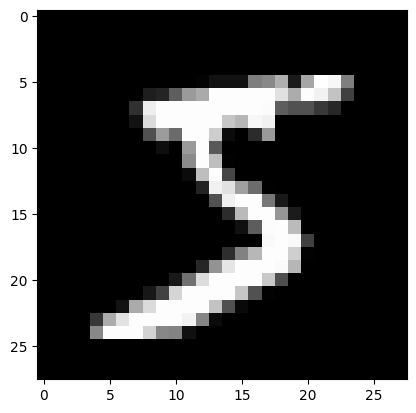

In [5]:
###########################################################################
# Inference
###########################################################################

# Load bitmap image
img = Image.open("./bmp/train_0.bmp", "r")
np_img = np.array(img)
pyplot.imshow(np_img, cmap=pyplot.get_cmap('gray'))

np_img_re = np.reshape(np_img, (1,1,28,28))
# 0 - 255 => 0 - 1 로 정규화, np.array => tensor 변환
data = Variable(torch.tensor((np_img_re / 255), dtype = torch.float32))
    
# Output of feedforwarding
output = model(data)
pred = output.data.max(1, keepdim=True)[1]
print('Predicted output: ' + ', '.join(map(str, pred.flatten().tolist())))

In [6]:
###########################################################################
# Save weights to a file
###########################################################################

# Save model
torch.save(model, "./mnist_weights.pt")
print("Model weights successfully saved to mnist_weights.pt")

Model weights successfully saved to mnist_weights.pt
